# e2e project - clustering + experimentation + retention cohorts

context : 
You are a Senior Product Analyst at FitTrack, a fast-growing mobile app company that provides fitness tracking and wellness coaching. Over the past year, FitTrack has grown from 100K to 500K monthly active users through various acquisition campaigns and feature launches. However, this rapid growth has created analytical blind spots.

The product team has been running A/B tests on new features while the marketing team experiments with different acquisition channels. Both teams collect data, but nobody has connected the dots between user acquisition quality, behavioral patterns, and long-term retention. Leadership suspects that some acquisition channels bring users who churn quickly, while certain user segments might be more valuable than others.

The VP of Product has asked you to conduct a comprehensive analysis that unifies these insights. She needs evidence-based recommendations to optimize both user acquisition strategy and product features. The stakes are high—FitTrack is preparing for Series B fundraising in Q2 and needs to demonstrate strong unit economics and user engagement metrics to investors. Your analysis will directly inform a $2M marketing budget reallocation and influence product roadmap priorities for the next six months.

## starting with clustering 

In [1]:
import pandas as pd

df = pd.read_csv("data/user_behavior_data.csv", parse_dates=["signup_date", "last_active_date"])
df

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel
0,USER_0001,2024-02-17,2024-03-08,14,0.00,email
1,USER_0002,2024-03-09,2024-03-09,4,0.00,paid_search
2,USER_0003,2024-01-26,2024-03-05,25,54.50,paid_search
3,USER_0004,2024-03-08,2024-03-13,5,0.00,organic
4,USER_0005,2024-01-24,2024-02-24,10,72.96,email
...,...,...,...,...,...,...
9995,USER_9996,2024-02-09,2024-02-16,12,116.33,organic
9996,USER_9997,2024-01-20,2024-01-25,20,69.84,email
9997,USER_9998,2024-01-23,2024-01-25,46,75.79,paid_search
9998,USER_9999,2024-01-01,2024-01-17,32,98.11,social_media


In [2]:
## steps to do clustering on the data
# 1. see the data and check if any outliers or anything 
# remove outliers (we can treat them differently afterwards if we want to)
# 2. build RFM 
    # - recency : pick a reference date (e.g. 2024-03-31) and subtract last_active_date — lower = more recent = better
    # - frequency : total_sessions
    # - monetary : revenue
# 3. log-transform RFM features (skew is likely — handle before scaling so outliers don't distort distances)
# 4. scale the data (StandardScaler)
# 5. elbow method + silhouette score to find optimal K
# 6. cluster the data using KMeans
# 7. inspect the clusters and see if they make sense and interpret results

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              10000 non-null  str           
 1   signup_date          10000 non-null  datetime64[us]
 2   last_active_date     10000 non-null  datetime64[us]
 3   total_sessions       10000 non-null  int64         
 4   revenue              9500 non-null   float64       
 5   acquisition_channel  10000 non-null  str           
dtypes: datetime64[us](2), float64(1), int64(1), str(2)
memory usage: 643.6 KB


In [4]:
df[df["revenue"].isnull()]

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel
29,USER_0030,2024-02-04,2024-02-05,8,NaN,social_media
50,USER_0051,2024-03-08,2024-03-15,12,NaN,referral
59,USER_0060,2024-01-03,2024-02-18,22,NaN,paid_search
69,USER_0070,2024-03-08,2024-03-09,14,NaN,organic
75,USER_0076,2024-02-05,2024-03-15,41,NaN,social_media
...,...,...,...,...,...,...
9880,USER_9881,2024-01-08,2024-01-08,2,NaN,social_media
9881,USER_9882,2024-02-28,2024-03-15,14,NaN,email
9920,USER_9921,2024-02-04,2024-02-04,8,NaN,email
9960,USER_9961,2024-02-09,2024-02-10,8,NaN,paid_search


In [5]:
df["revenue"] = df["revenue"].fillna(0)
df["revenue"].isnull().sum()

np.int64(0)

In [6]:
df.describe(include="all")

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel
count,10000,10000,10000,10000.00000,10000.000000,10000
unique,10000,NaN,NaN,NaN,NaN,5
top,USER_0001,NaN,NaN,NaN,NaN,social_media
freq,1,NaN,NaN,NaN,NaN,2958
mean,NaN,2024-02-04 19:32:52.800000,2024-02-17 13:06:57.600000,22.91110,40.033382,NaN
min,NaN,2024-01-01 00:00:00,2024-01-01 00:00:00,0.00000,0.000000,NaN
25%,NaN,2024-01-18 00:00:00,2024-01-30 00:00:00,6.00000,0.000000,NaN
50%,NaN,2024-02-05 00:00:00,2024-02-20 00:00:00,13.00000,19.975000,NaN
75%,NaN,2024-02-23 00:00:00,2024-03-10 00:00:00,23.00000,66.455000,NaN
max,NaN,2024-03-11 00:00:00,2024-03-15 00:00:00,479.00000,528.680000,NaN


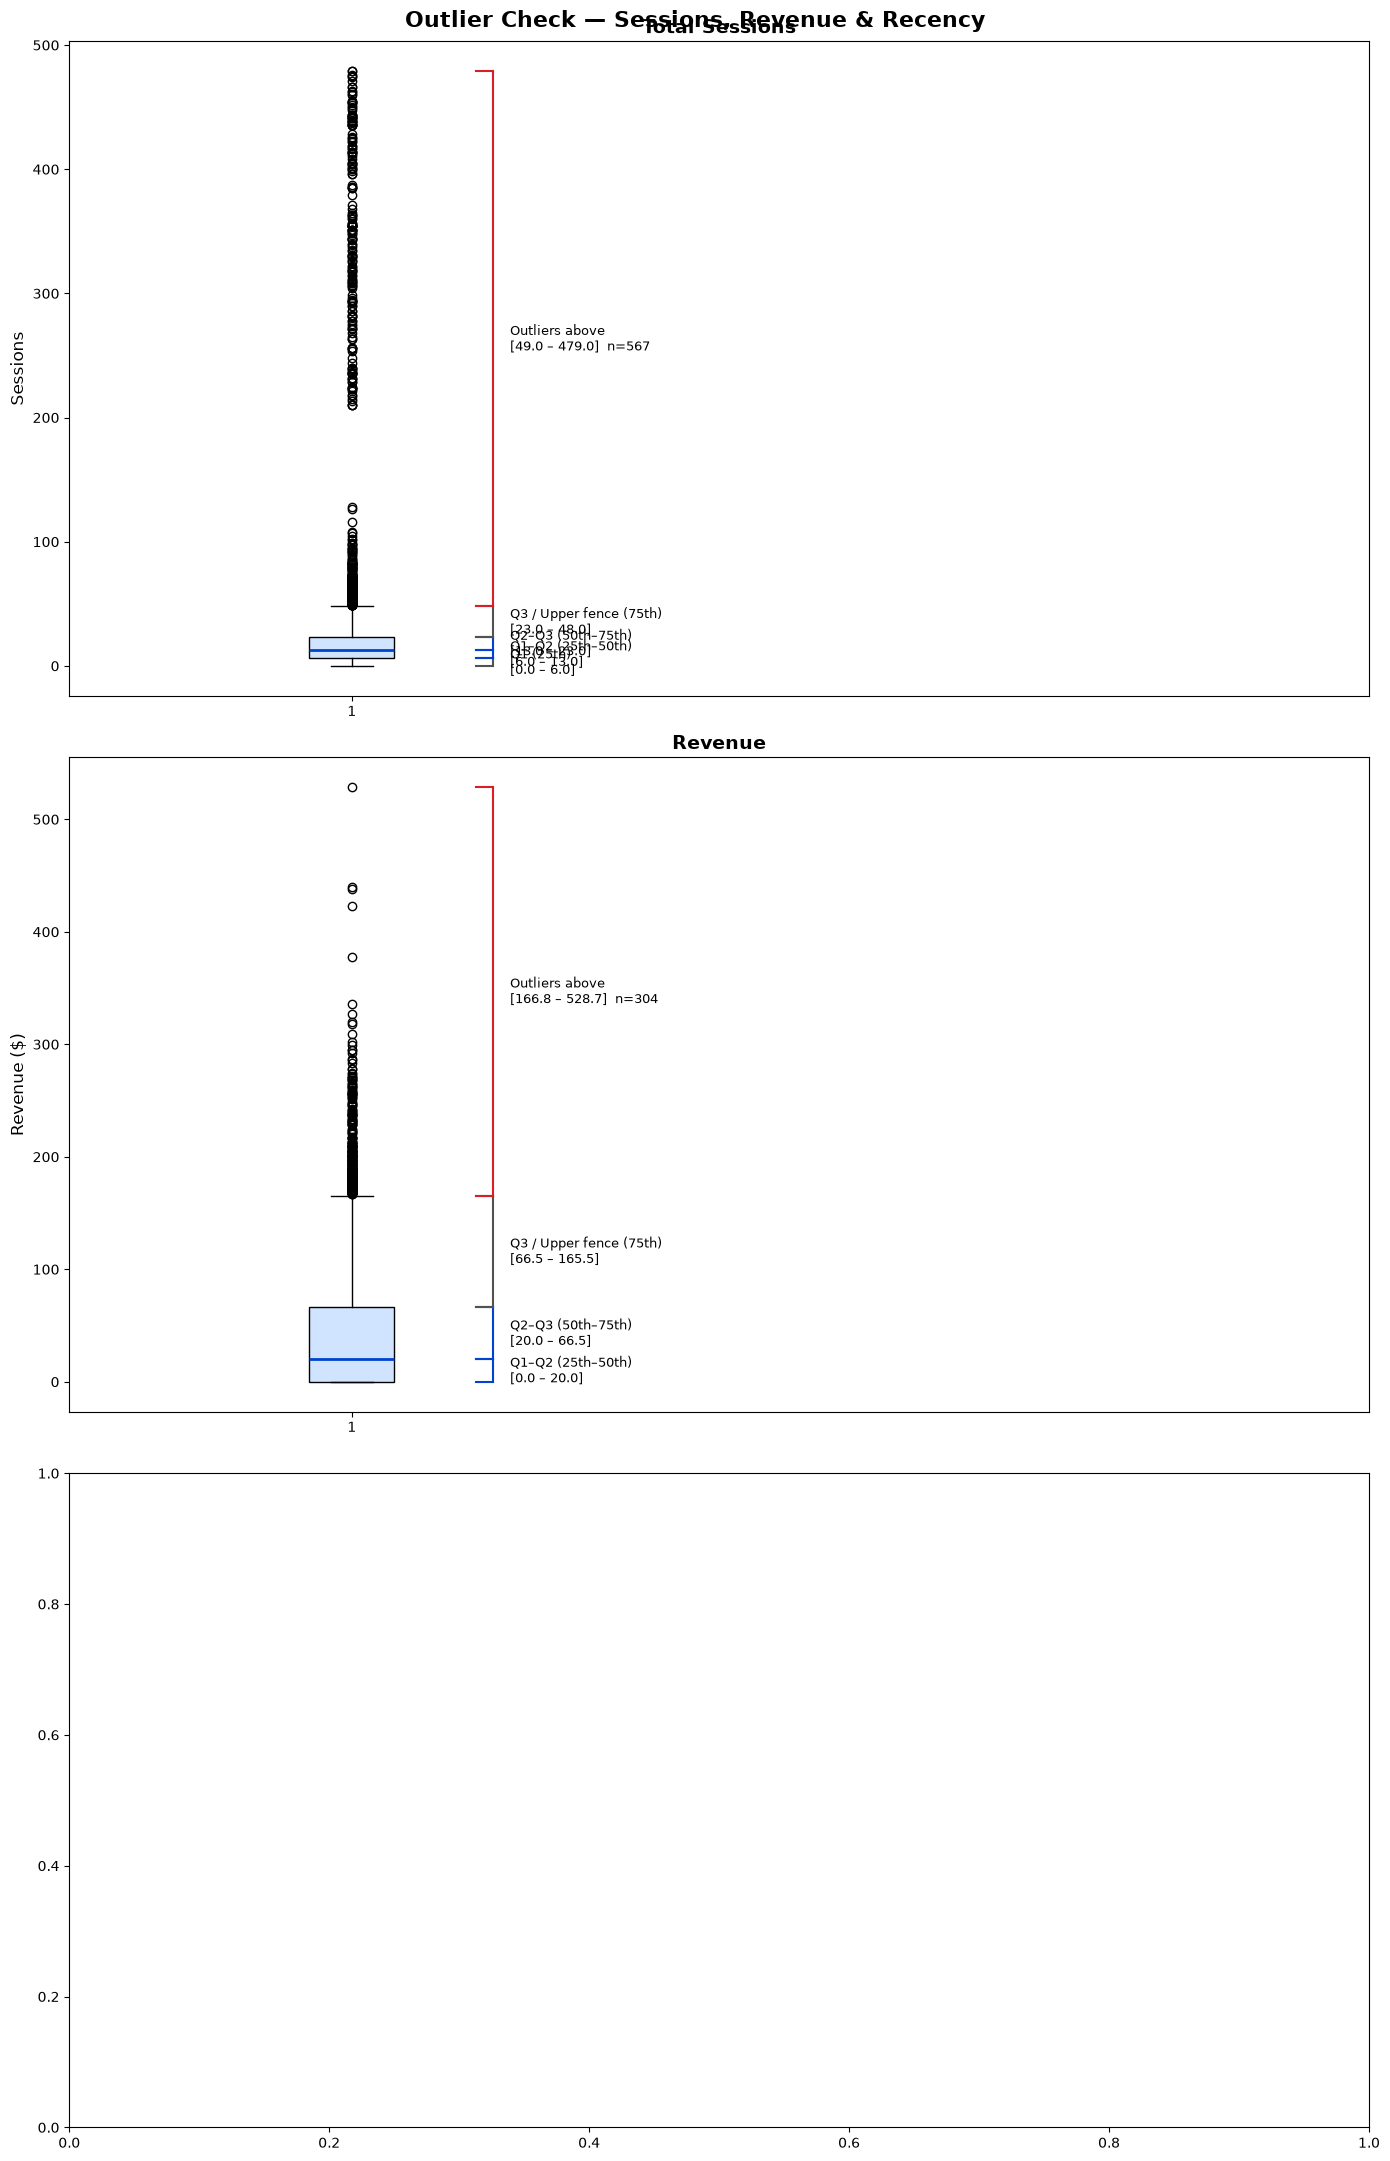

In [7]:
import matplotlib.pyplot as plt

def draw_bracket(ax, y_low, y_high, x, label, color="gray", tick=0.03, fontsize=9):
    ax.plot([x, x], [y_low, y_high], color=color, lw=1.5, clip_on=False)
    ax.plot([x - tick, x], [y_low,  y_low],  color=color, lw=1.5, clip_on=False)
    ax.plot([x - tick, x], [y_high, y_high], color=color, lw=1.5, clip_on=False)
    ax.text(x + tick, (y_low + y_high) / 2, label, va="center", fontsize=fontsize, clip_on=False)

def annotated_boxplot(ax, series, title, ylabel):
    q1  = series.quantile(0.25)
    q2  = series.quantile(0.50)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_whisker = series[series >= lower_fence].min()
    upper_whisker = series[series <= upper_fence].max()

    ax.boxplot(series.dropna(), patch_artist=True,
               boxprops=dict(facecolor="#d0e4ff"),
               medianprops=dict(color="#0043ce", linewidth=2))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim(0.5, 2.8)

    x_bracket = 1.25

    segments = [
        (lower_whisker, q1,            "Q1 (25th)\n[{:.1f} – {:.1f}]".format(lower_whisker, q1),            "#525252"),
        (q1,            q2,            "Q1–Q2 (25th–50th)\n[{:.1f} – {:.1f}]".format(q1, q2),              "#0043ce"),
        (q2,            q3,            "Q2–Q3 (50th–75th)\n[{:.1f} – {:.1f}]".format(q2, q3),              "#0043ce"),
        (q3,            upper_whisker, "Q3 / Upper fence (75th)\n[{:.1f} – {:.1f}]".format(q3, upper_whisker), "#525252"),
    ]

    below = series[series < lower_fence]
    above = series[series > upper_fence]
    if len(below):
        segments.insert(0, (below.min(), lower_whisker,
                            "Outliers below\n[{:.1f} – {:.1f}]  n={}".format(below.min(), below.max(), len(below)),
                            "#da1e28"))
    if len(above):
        segments.append((upper_whisker, above.max(),
                         "Outliers above\n[{:.1f} – {:.1f}]  n={}".format(above.min(), above.max(), len(above)),
                         "#da1e28"))

    for y_low, y_high, label, color in segments:
        if y_high > y_low:
            draw_bracket(ax, y_low, y_high, x_bracket, label, color=color, fontsize=9)

fig, axes = plt.subplots(3, 1, figsize=(14, 22))
annotated_boxplot(axes[0], df["total_sessions"], "Total Sessions", "Sessions")
annotated_boxplot(axes[1], df["revenue"],        "Revenue",        "Revenue ($)")


plt.suptitle("Outlier Check — Sessions, Revenue & Recency", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
import numpy as np

def outlier_summary(series, name):
    q1  = series.quantile(0.25)
    q2  = series.quantile(0.50)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    below = series[series < lower_fence]
    above = series[series > upper_fence]

    rows = {
        "Q1 (25th pct)":              {"value": q1,                 "segment min": series.min(),         "segment max": q1,                   "count": (series <= q1).sum()},
        "Q2 (50th pct)":              {"value": q2,                 "segment min": q1,                   "segment max": q2,                   "count": ((series > q1) & (series <= q2)).sum()},
        "Q3 (75th pct)":              {"value": q3,                 "segment min": q2,                   "segment max": q3,                   "count": ((series > q2) & (series <= q3)).sum()},
        "Q4 (100th pct)":             {"value": series.max(),       "segment min": q3,                   "segment max": series.max(),         "count": (series > q3).sum()},
        "IQR":                        {"value": iqr,                "segment min": "-",                  "segment max": "-",                  "count": "-"},
        "Lower fence (Q1 - 1.5×IQR)":{"value": round(lower_fence, 2), "segment min": below.min() if len(below) else "-", "segment max": below.max() if len(below) else "-", "count": len(below)},
        "Upper fence (Q3 + 1.5×IQR)":{"value": round(upper_fence, 2), "segment min": above.min() if len(above) else "-", "segment max": above.max() if len(above) else "-", "count": len(above)},
    }

    summary = pd.DataFrame(rows).T
    summary.index.name = name
    return summary

for col in ["total_sessions", "revenue"]:
    print(f"\n{'='*60}")
    display(outlier_summary(df[col], col))

,value,segment min,segment max,count
total_sessions,,,,
Q1 (25th pct),6.0,0.0,6.0,2684.0
Q2 (50th pct),13.0,6.0,13.0,2552.0
Q3 (75th pct),23.0,13.0,23.0,2300.0
Q4 (100th pct),479.0,23.0,479.0,2464.0
IQR,17.0,-,-,-
Lower fence (Q1 - 1.5×IQR),-19.5,-,-,0
Upper fence (Q3 + 1.5×IQR),48.5,49.0,479.0,567.0


,value,segment min,segment max,count
revenue,,,,
Q1 (25th pct),0.0,0.0,0.0,4317.0
Q2 (50th pct),19.975,0.0,19.975,683.0
Q3 (75th pct),66.455,19.975,66.455,2500.0
Q4 (100th pct),528.68,66.455,528.68,2500.0
IQR,66.455,-,-,-
Lower fence (Q1 - 1.5×IQR),-99.68,-,-,0
Upper fence (Q3 + 1.5×IQR),166.14,166.75,528.68,304.0


In [9]:
df_raw = df.copy()

def iqr_fences(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

sessions_lower, sessions_upper = iqr_fences(df["total_sessions"])
revenue_lower,  revenue_upper  = iqr_fences(df["revenue"])

high_sessions_df = df[df["total_sessions"] > sessions_upper].copy()
high_revenue_df  = df[df["revenue"]        > revenue_upper].copy()

df = df[
    (df["total_sessions"].between(sessions_lower, sessions_upper)) &
    (df["revenue"].between(revenue_lower, revenue_upper))
].copy()

print(f"Original:          {len(df_raw):,} rows")
print(f"After removing:    {len(df):,} rows")
print(f"High sessions df:  {len(high_sessions_df):,} rows  (sessions > {sessions_upper:.1f})")
print(f"High revenue df:   {len(high_revenue_df):,} rows  (revenue > {revenue_upper:.1f})")

Original:          10,000 rows
After removing:    9,154 rows
High sessions df:  567 rows  (sessions > 48.5)
High revenue df:   304 rows  (revenue > 166.1)


In [10]:
from scipy.stats import gaussian_kde

def distribution_plot(ax, series, title, xlabel, color="#0043ce"):
    kde = gaussian_kde(series.dropna())
    x   = np.linspace(series.min(), series.max(), 500)
    y   = kde(x)

    ax.plot(x, y, color=color, lw=2)
    ax.fill_between(x, y, alpha=0.2, color=color)

    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    for val, label, ls in [(q1, "Q1", "--"), (q2, "Median", "-"), (q3, "Q3", "--")]:
        ax.axvline(val, color="#525252", linestyle=ls, lw=1.2,
                   label=f"{label}: {val:.1f}")

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.legend(fontsize=10)

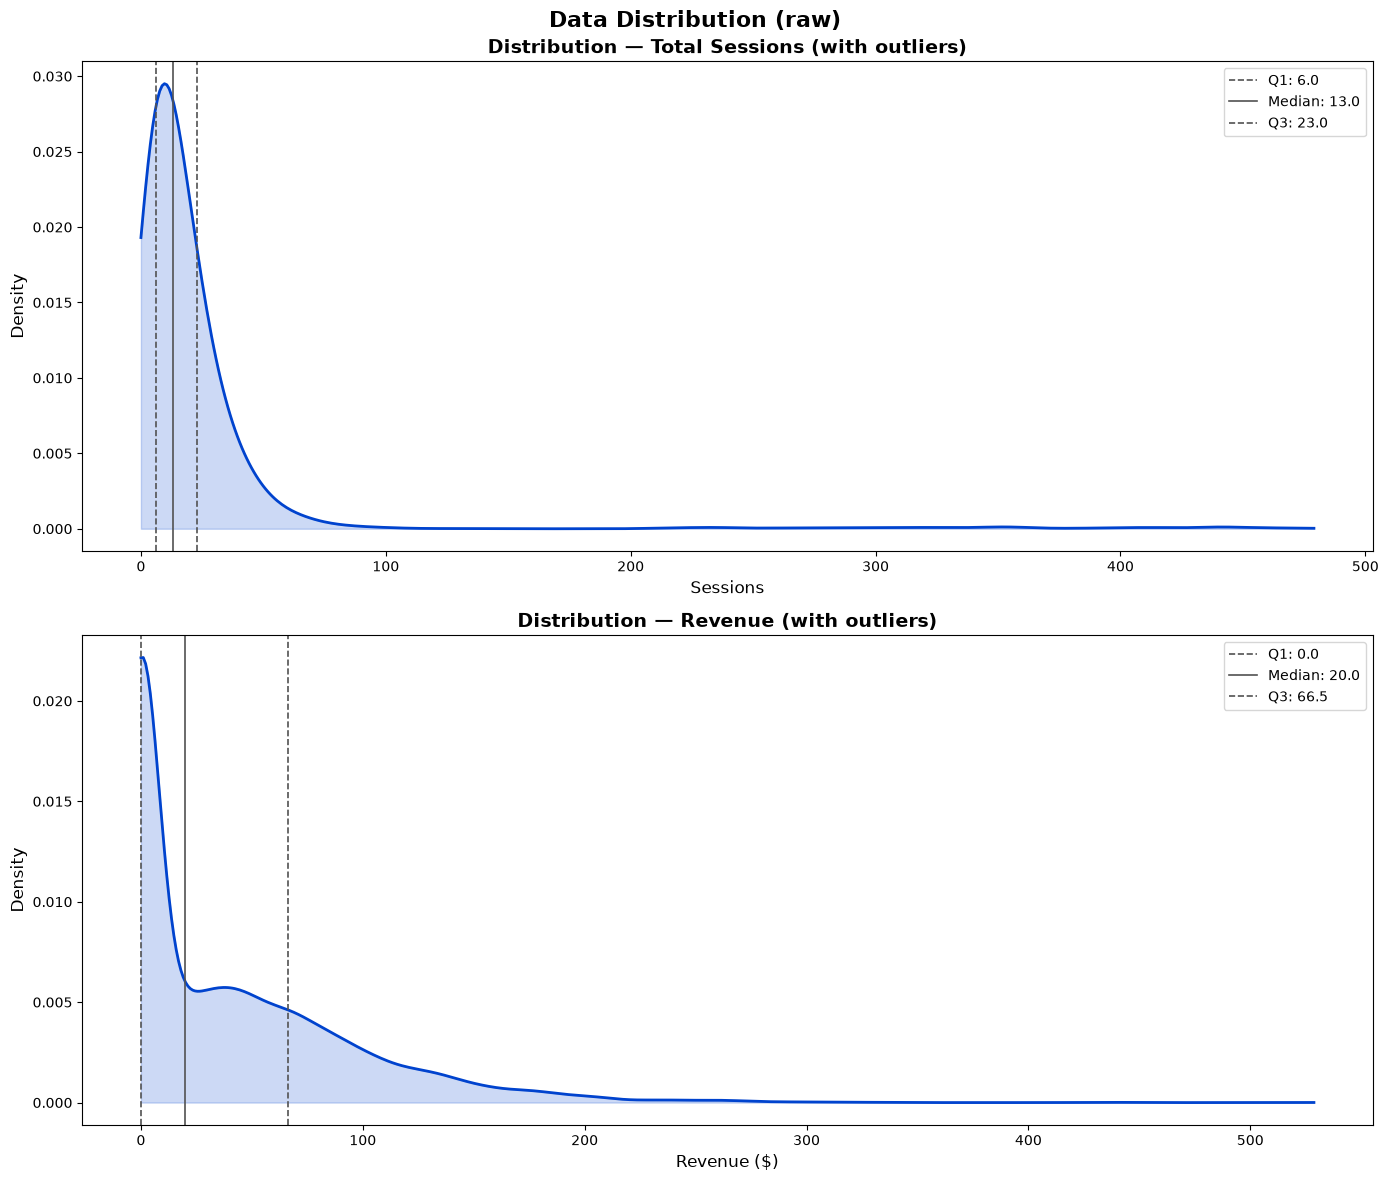

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
distribution_plot(axes[0], df_raw["total_sessions"], "Distribution — Total Sessions (with outliers)", "Sessions")
distribution_plot(axes[1], df_raw["revenue"],        "Distribution — Revenue (with outliers)",        "Revenue ($)")

plt.suptitle("Data Distribution (raw)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

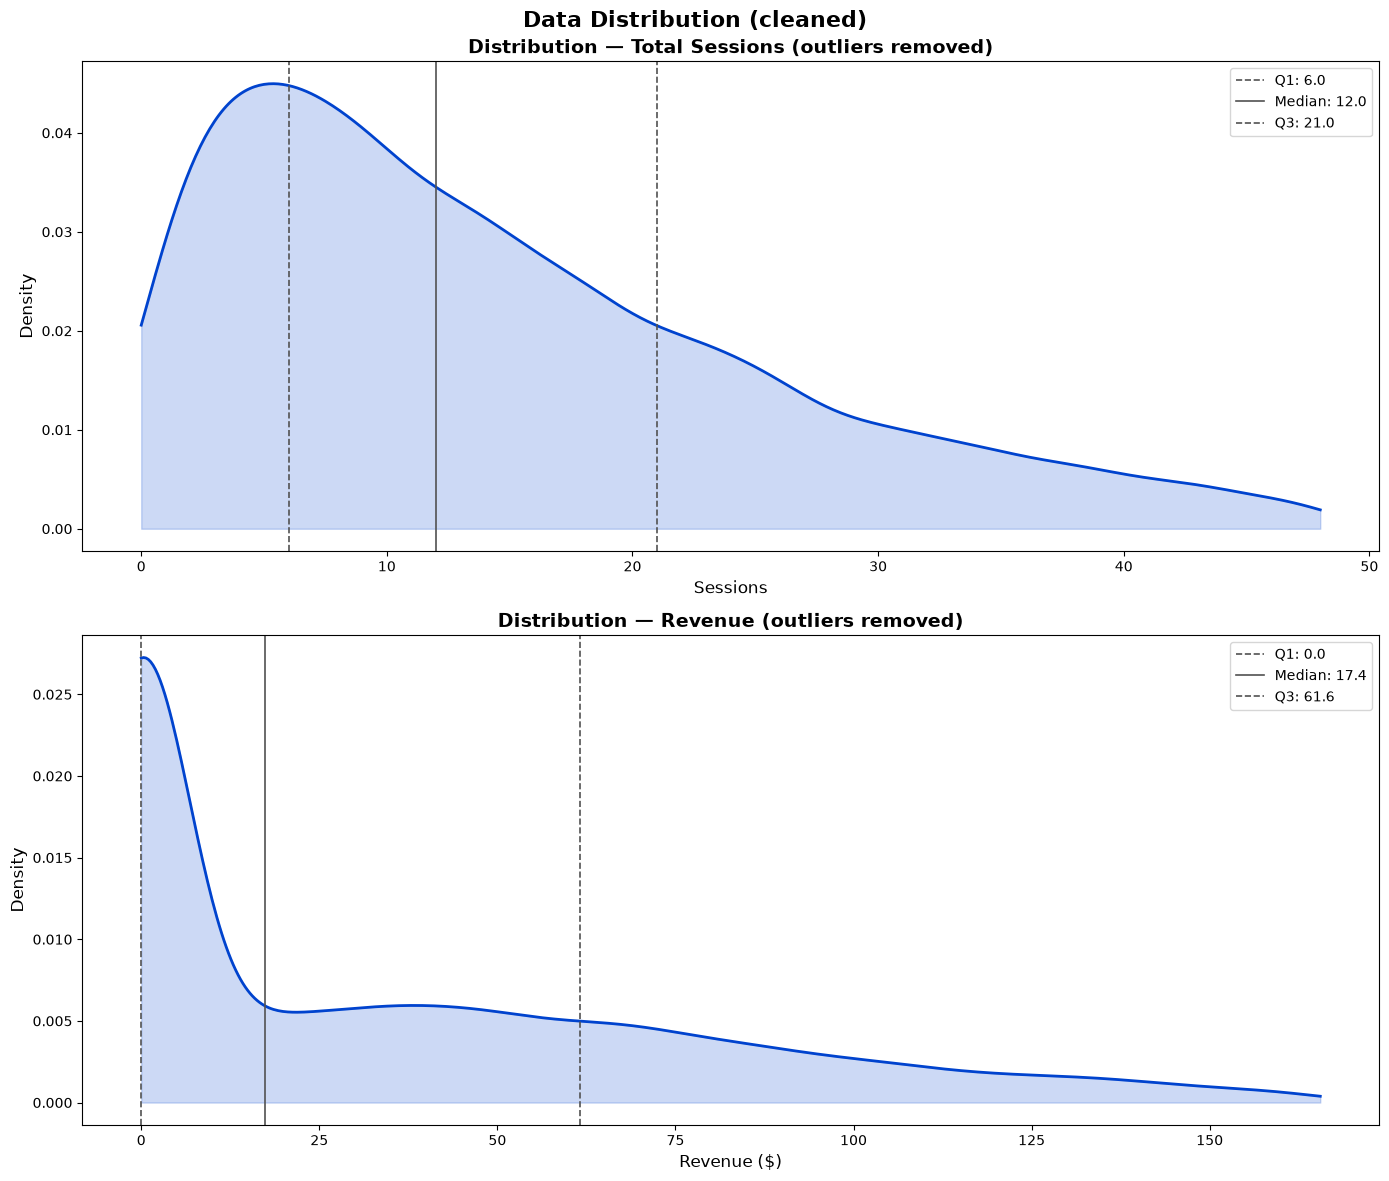

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
distribution_plot(axes[0], df["total_sessions"], "Distribution — Total Sessions (outliers removed)", "Sessions")
distribution_plot(axes[1], df["revenue"],        "Distribution — Revenue (outliers removed)",        "Revenue ($)")

plt.suptitle("Data Distribution (cleaned)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
df.describe(include="all")

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel
count,9154,9154,9154,9154.000000,9154.000000,9154
unique,9154,NaN,NaN,NaN,NaN,5
top,USER_0001,NaN,NaN,NaN,NaN,social_media
freq,1,NaN,NaN,NaN,NaN,2702
mean,NaN,2024-02-04 19:39:29.849246,2024-02-16 22:25:08.586410,14.548285,34.663099,NaN
min,NaN,2024-01-01 00:00:00,2024-01-01 00:00:00,0.000000,0.000000,NaN
25%,NaN,2024-01-18 00:00:00,2024-01-30 00:00:00,6.000000,0.000000,NaN
50%,NaN,2024-02-05 00:00:00,2024-02-19 00:00:00,12.000000,17.445000,NaN
75%,NaN,2024-02-23 00:00:00,2024-03-09 00:00:00,21.000000,61.590000,NaN
max,NaN,2024-03-11 00:00:00,2024-03-15 00:00:00,48.000000,165.520000,NaN


In [14]:
reference_date = pd.Timestamp("2024-03-31")

rfm_df = df[["user_id"]].copy()
rfm_df["recency"]   = (reference_date - df["last_active_date"]).dt.days.values
rfm_df["frequency"] = df["total_sessions"].values
rfm_df["monetary"]  = df["revenue"].values
rfm_df.head()

,user_id,recency,frequency,monetary
0,USER_0001,23,14,0.00
1,USER_0002,22,4,0.00
2,USER_0003,26,25,54.50
3,USER_0004,18,5,0.00
4,USER_0005,36,10,72.96


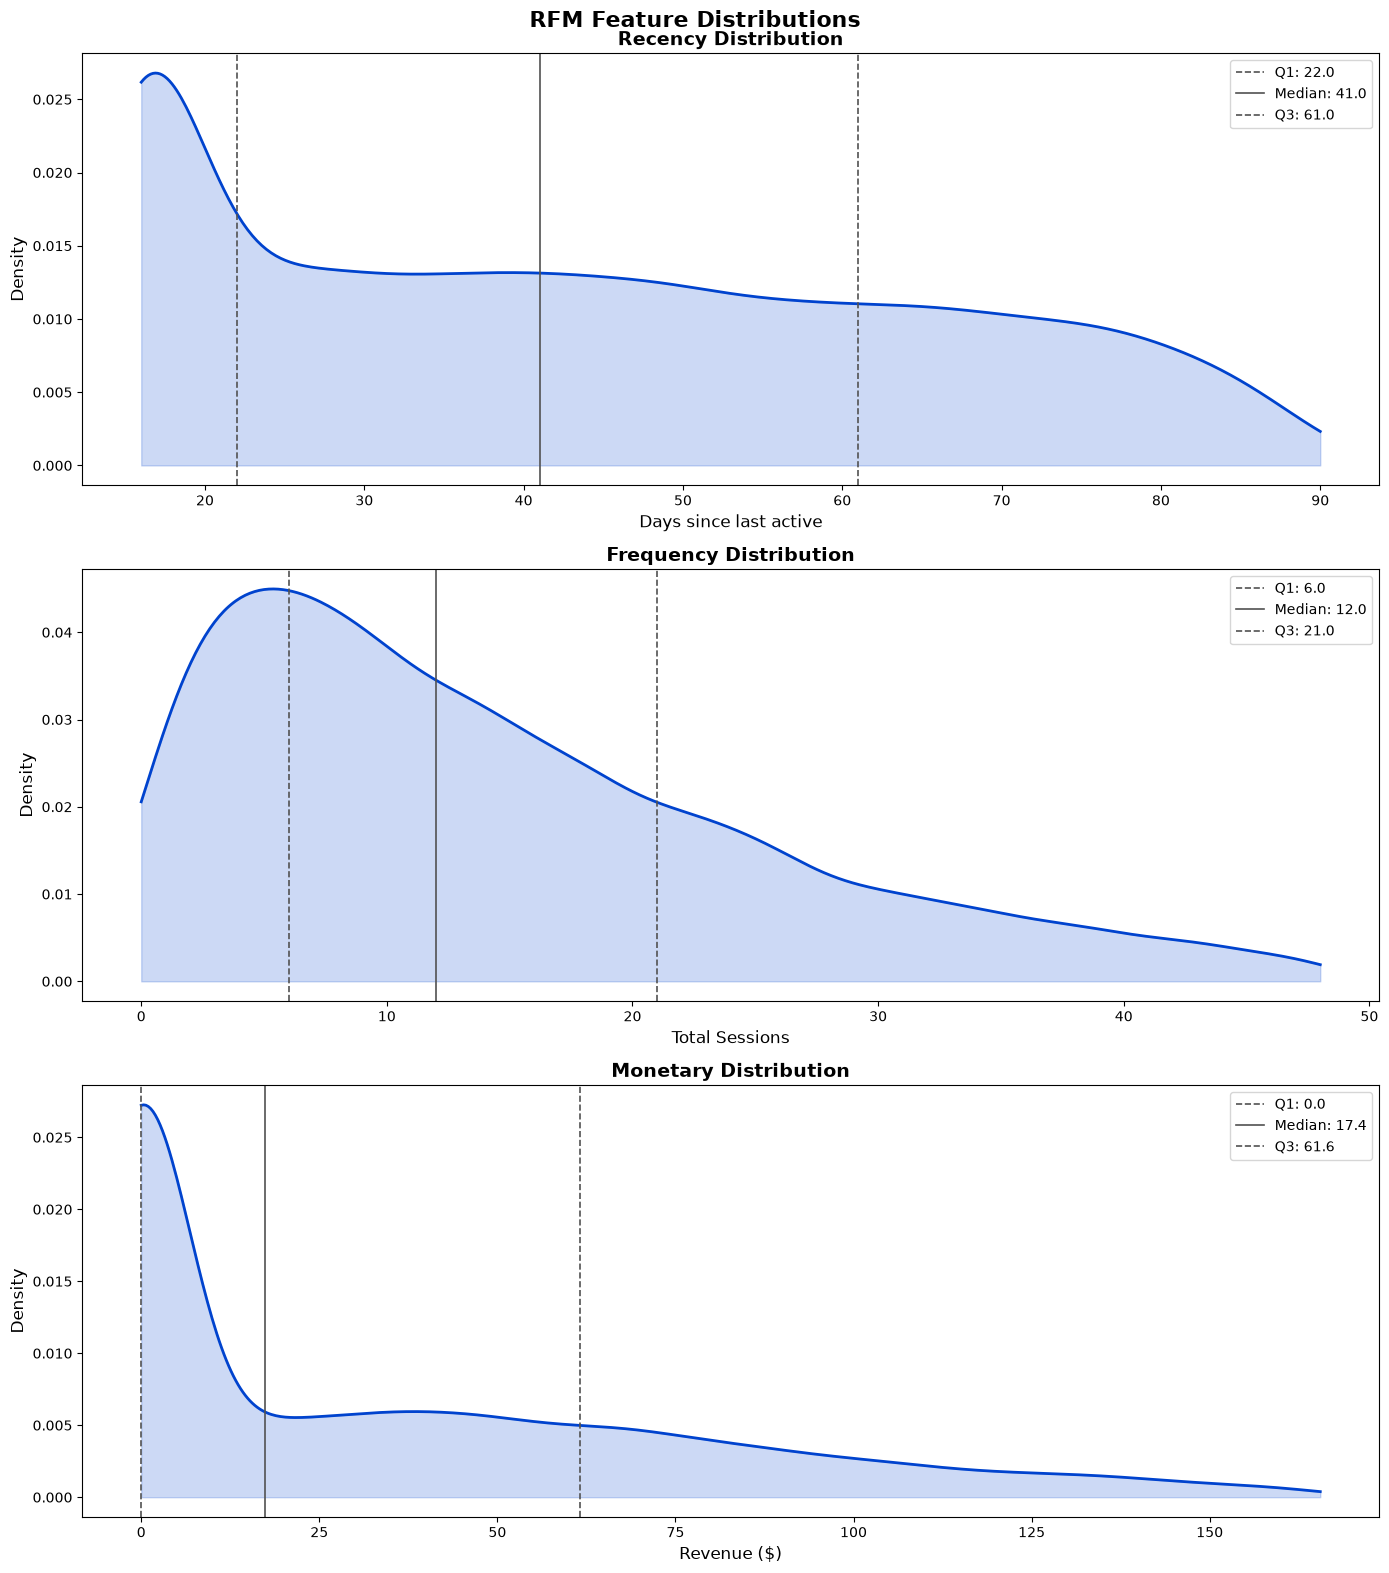

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

distribution_plot(axes[0], rfm_df["recency"],   "Recency Distribution",   "Days since last active")
distribution_plot(axes[1], rfm_df["frequency"], "Frequency Distribution", "Total Sessions")
distribution_plot(axes[2], rfm_df["monetary"],  "Monetary Distribution",  "Revenue ($)")

plt.suptitle("RFM Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Why log-transform before scaling?

K-Means clusters by **Euclidean distance** — it treats a gap of 10 the same whether it's between 0→10 or 38→48. But behaviorally those are very different: 0 vs 10 sessions is churned vs active, while 38 vs 48 is basically the same user. Raw numbers make K-Means blind to that.

**Log-transform compresses the high end and stretches the low end**, so gaps that matter (near zero) count more, and gaps that don't (at the top) count less. We use `log1p` (= `log(x + 1)`) instead of `log` because frequency and monetary both have zeros — `log(0)` is undefined, `log1p(0) = 0`.

A second reason: StandardScaler assumes roughly symmetric data. A skewed distribution causes the scaler to stretch the axis in a way that still distorts distances. Log-transforming first brings the distribution closer to symmetric so the scaler works correctly.

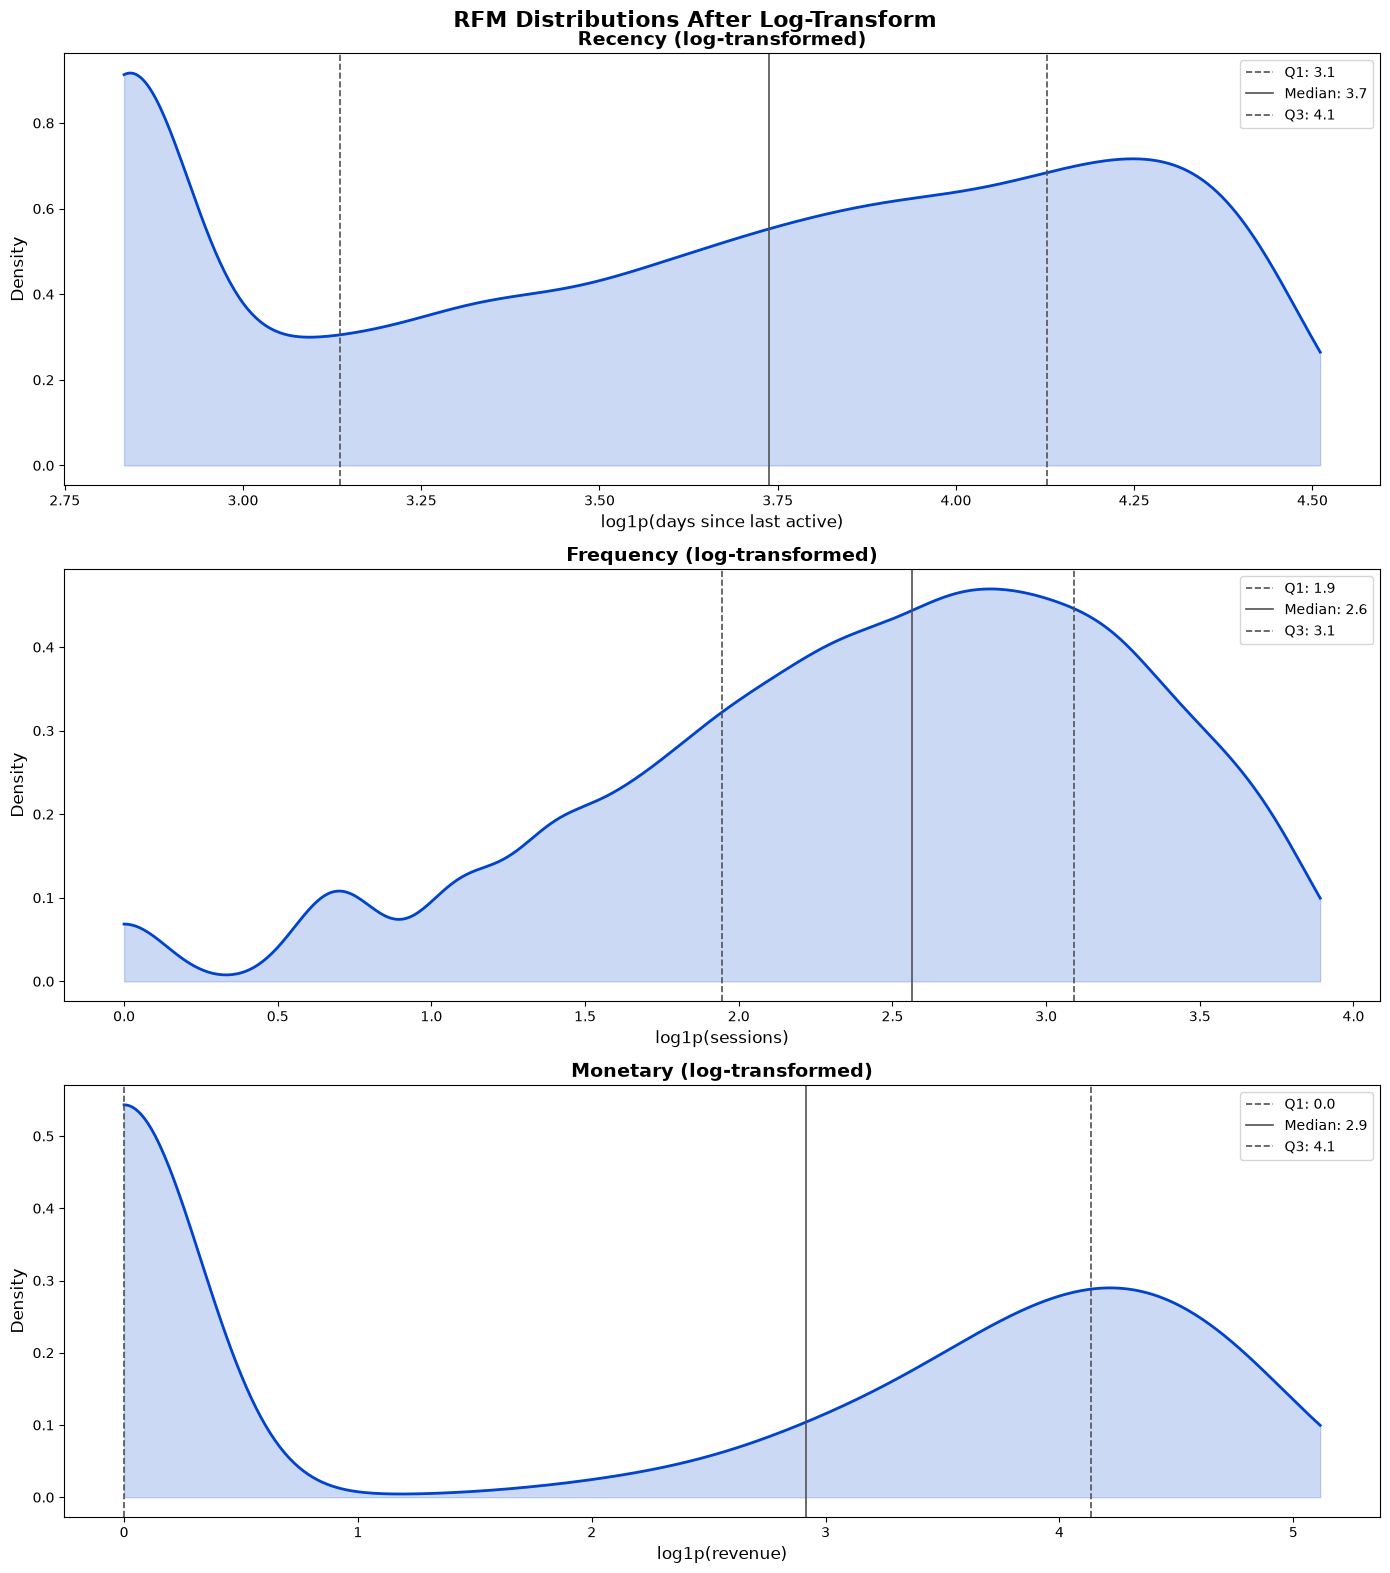

In [16]:
rfm_log = rfm_df.copy()
rfm_log["recency"]   = np.log1p(rfm_df["recency"])
rfm_log["frequency"] = np.log1p(rfm_df["frequency"])
rfm_log["monetary"]  = np.log1p(rfm_df["monetary"])

fig, axes = plt.subplots(3, 1, figsize=(14, 16))
distribution_plot(axes[0], rfm_log["recency"],   "Recency (log-transformed)",   "log1p(days since last active)")
distribution_plot(axes[1], rfm_log["frequency"], "Frequency (log-transformed)", "log1p(sessions)")
distribution_plot(axes[2], rfm_log["monetary"],  "Monetary (log-transformed)",  "log1p(revenue)")

plt.suptitle("RFM Distributions After Log-Transform", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
rfm_df.describe(include="all")

,user_id,recency,frequency,monetary
count,9154,9154.000000,9154.000000,9154.000000
unique,9154,NaN,NaN,NaN
top,USER_0001,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,43.065873,14.548285,34.663099
std,NaN,22.065631,11.078226,42.106560
min,NaN,16.000000,0.000000,0.000000
25%,NaN,22.000000,6.000000,0.000000
50%,NaN,41.000000,12.000000,17.445000
75%,NaN,61.000000,21.000000,61.590000


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features = ["recency", "frequency", "monetary"]

rfm_scaled = rfm_log.copy()
rfm_scaled[features] = scaler.fit_transform(rfm_log[features])

rfm_scaled[features].describe().round(3)

,recency,frequency,monetary
count,9154.000,9154.000,9154.000
mean,0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-1.475,-2.824,-1.075
25%,-0.926,-0.570,-1.075
50%,0.169,0.147,0.363
75%,0.877,0.757,0.966
max,1.575,1.684,1.448


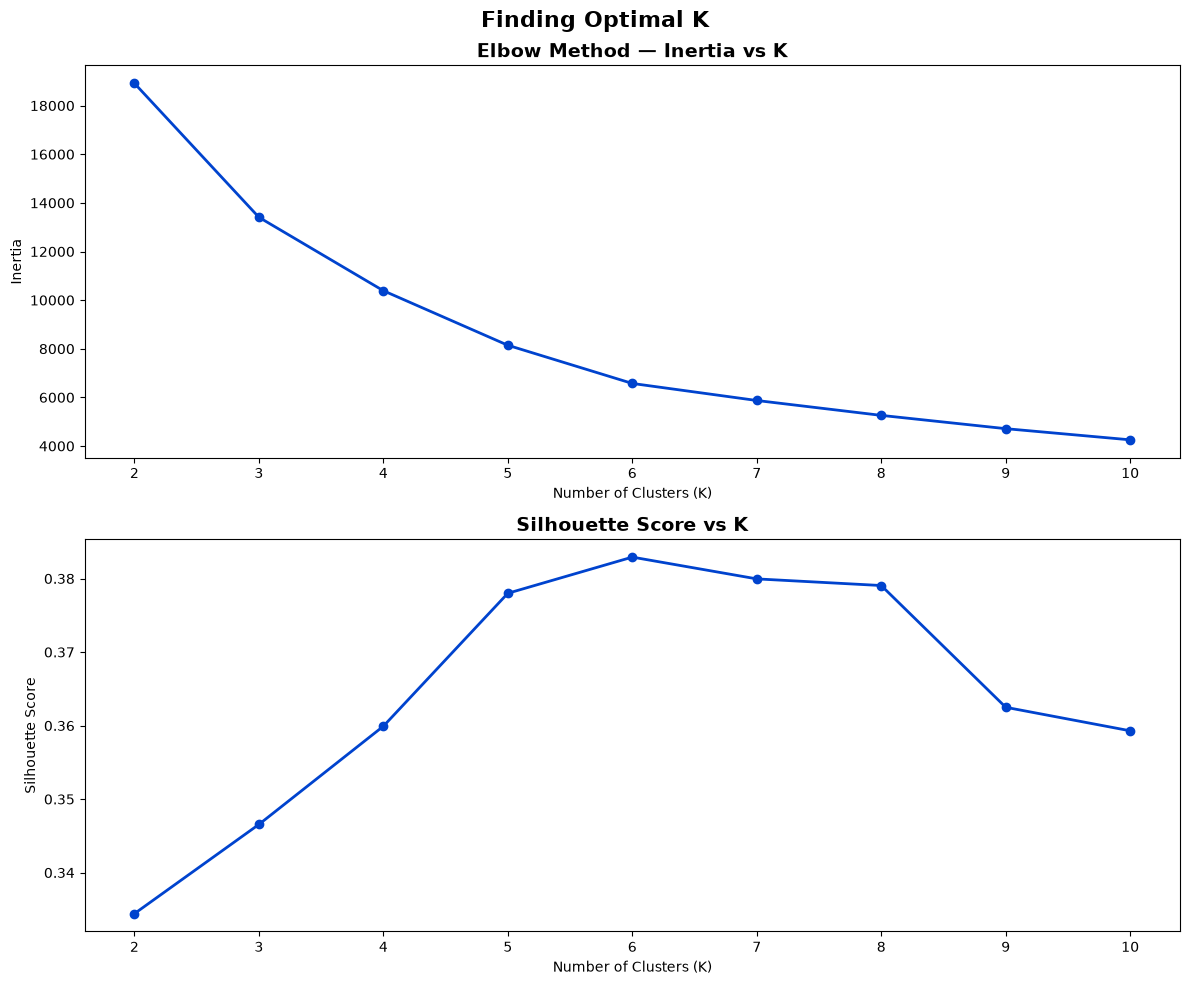


Silhouette scores:
  K=2: 0.3344
  K=3: 0.3466
  K=4: 0.3599
  K=5: 0.3780
  K=6: 0.3829
  K=7: 0.3800
  K=8: 0.3791
  K=9: 0.3625
  K=10: 0.3593


In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = rfm_scaled[features].values

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

axes[0].plot(K_range, inertias, marker="o", color="#0043ce", lw=2)
axes[0].set_title("Elbow Method — Inertia vs K", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, silhouettes, marker="o", color="#0043ce", lw=2)
axes[1].set_title("Silhouette Score vs K", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(K_range))

plt.suptitle("Finding Optimal K", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k}: {s:.4f}")

In [20]:
km_final = KMeans(n_clusters=6, random_state=42, n_init=10)
rfm_df["cluster"] = km_final.fit_predict(X)

# cluster sizes
print("Cluster sizes:")
print(rfm_df["cluster"].value_counts().sort_index())

rfm_df.head()

Cluster sizes:
cluster
0    1432
1    1905
2    1593
3    1734
4    1131
5    1359
Name: count, dtype: int64


,user_id,recency,frequency,monetary,cluster
0,USER_0001,23,14,0.00,0
1,USER_0002,22,4,0.00,4
2,USER_0003,26,25,54.50,3
3,USER_0004,18,5,0.00,0
4,USER_0005,36,10,72.96,1


In [21]:
df = df.merge(rfm_df[["user_id", "recency", "frequency", "monetary", "cluster"]], on="user_id", how="left")
df.head()

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary,cluster
0,USER_0001,2024-02-17,2024-03-08,14,0.00,email,23,14,0.00,0
1,USER_0002,2024-03-09,2024-03-09,4,0.00,paid_search,22,4,0.00,4
2,USER_0003,2024-01-26,2024-03-05,25,54.50,paid_search,26,25,54.50,3
3,USER_0004,2024-03-08,2024-03-13,5,0.00,organic,18,5,0.00,0
4,USER_0005,2024-01-24,2024-02-24,10,72.96,email,36,10,72.96,1


In [22]:
df.groupby("cluster")["user_id"].count().reset_index().rename(columns={"user_id": "num_users"})

,cluster,num_users
0,0,1432
1,1,1905
2,2,1593
3,3,1734
4,4,1131
5,5,1359


In [23]:
profile = df.groupby("cluster")[["recency", "frequency", "monetary"]].agg(["min", "mean", "max"]).round(2)

# flatten column names
profile.columns = ["_".join(col) for col in profile.columns]

# add plain-english summary of mean values
profile["summary"] = (
    "Recency avg: "   + profile["recency_mean"].astype(str)   + " days | " +
    "Frequency avg: " + profile["frequency_mean"].astype(str) + " sessions | " +
    "Monetary avg: $" + profile["monetary_mean"].astype(str)
)

profile

,recency_min,recency_mean,recency_max,frequency_min,frequency_mean,frequency_max,monetary_min,monetary_mean,monetary_max,summary
cluster,,,,,,,,,,
0,16,19.56,34,3,21.14,48,0.00,0.05,6.32,Recency avg: 19.56 days | Frequency avg: 21.14...
1,32,56.84,90,7,16.74,48,6.41,63.41,165.52,Recency avg: 56.84 days | Frequency avg: 16.74...
2,31,56.01,90,7,17.13,48,0.00,0.11,6.39,Recency avg: 56.01 days | Frequency avg: 17.13...
3,16,19.96,35,3,20.49,48,6.49,63.41,165.35,Recency avg: 19.96 days | Frequency avg: 20.49...
4,16,53.41,90,0,3.38,7,0.00,0.09,6.57,Recency avg: 53.41 days | Frequency avg: 3.38 ...
5,16,54.22,90,0,3.22,7,6.25,63.43,164.59,Recency avg: 54.22 days | Frequency avg: 3.22 ...


In [24]:
high_sessions_ids = set(high_sessions_df["user_id"])
high_revenue_ids  = set(high_revenue_df["user_id"])
overlap_ids       = high_sessions_ids & high_revenue_ids

overlap_df = df_raw[df_raw["user_id"].isin(overlap_ids)].copy()

print(f"High sessions users:  {len(high_sessions_ids):,}")
print(f"High revenue users:   {len(high_revenue_ids):,}")
print(f"Overlap (both):       {len(overlap_ids):,}  ({len(overlap_ids)/len(high_sessions_ids)*100:.1f}% of high-sessions, {len(overlap_ids)/len(high_revenue_ids)*100:.1f}% of high-revenue)")

# RFM metrics
overlap_df["recency"]   = (reference_date - overlap_df["last_active_date"]).dt.days
overlap_df["frequency"] = overlap_df["total_sessions"]
overlap_df["monetary"]  = overlap_df["revenue"]

# sort by monetary desc, then frequency desc
overlap_df = overlap_df.sort_values(["monetary", "frequency"], ascending=False).reset_index(drop=True)

overlap_df

High sessions users:  567
High revenue users:   304
Overlap (both):       25  (4.4% of high-sessions, 8.2% of high-revenue)


,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary
0,USER_6763,2024-03-08,2024-03-15,63,286.26,social_media,16,63,286.26
1,USER_1290,2024-03-03,2024-03-15,78,273.97,social_media,16,78,273.97
2,USER_9640,2024-01-20,2024-01-25,452,268.53,referral,66,452,268.53
3,USER_4198,2024-01-02,2024-03-15,58,255.73,organic,16,58,255.73
4,USER_9319,2024-01-12,2024-01-15,55,242.22,paid_search,76,55,242.22
5,USER_3162,2024-03-04,2024-03-15,71,237.77,organic,16,71,237.77
6,USER_9588,2024-01-04,2024-02-07,244,216.73,social_media,53,244,216.73
7,USER_2355,2024-01-14,2024-01-21,60,216.53,email,70,60,216.53
8,USER_3757,2024-02-28,2024-03-06,439,207.68,social_media,25,439,207.68
9,USER_0620,2024-02-21,2024-03-10,411,205.02,email,21,411,205.02


In [25]:
high_sessions_df = high_sessions_df[~high_sessions_df["user_id"].isin(overlap_ids)].reset_index(drop=True)
high_revenue_df  = high_revenue_df[~high_revenue_df["user_id"].isin(overlap_ids)].reset_index(drop=True)

print(f"High sessions df (excl. overlap): {len(high_sessions_df):,} users")
print(f"High revenue df  (excl. overlap): {len(high_revenue_df):,} users")
print(f"Overlap df:                        {len(overlap_df):,} users")

High sessions df (excl. overlap): 542 users
High revenue df  (excl. overlap): 279 users
Overlap df:                        25 users


In [26]:
for name, frame in [("high_sessions_df", high_sessions_df), ("high_revenue_df", high_revenue_df)]:
    frame["recency"]   = (reference_date - frame["last_active_date"]).dt.days
    frame["frequency"] = frame["total_sessions"]
    frame["monetary"]  = frame["revenue"]

print("high_sessions_df:")
display(high_sessions_df.sort_values("frequency", ascending=False).reset_index(drop=True))

print("\nhigh_revenue_df:")
display(high_revenue_df.sort_values("monetary", ascending=False).reset_index(drop=True))

high_sessions_df:


,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary
0,USER_1406,2024-03-11,2024-03-15,479,75.18,social_media,16,479,75.18
1,USER_3491,2024-01-29,2024-01-29,479,0.00,referral,62,479,0.00
2,USER_1934,2024-01-12,2024-02-08,476,79.89,social_media,52,476,79.89
3,USER_9431,2024-01-16,2024-01-17,474,43.32,email,74,474,43.32
4,USER_4855,2024-02-08,2024-03-15,471,34.57,paid_search,16,471,34.57
...,...,...,...,...,...,...,...,...,...
537,USER_1473,2024-01-10,2024-03-15,49,50.05,email,16,49,50.05
538,USER_8972,2024-02-26,2024-03-15,49,0.00,social_media,16,49,0.00
539,USER_9010,2024-02-13,2024-03-15,49,47.75,paid_search,16,49,47.75
540,USER_1439,2024-02-26,2024-03-05,49,0.00,referral,26,49,0.00



high_revenue_df:


,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary
0,USER_4226,2024-03-03,2024-03-15,13,528.68,social_media,16,13,528.68
1,USER_4766,2024-03-10,2024-03-15,17,439.91,social_media,16,17,439.91
2,USER_4663,2024-01-27,2024-01-28,9,438.47,paid_search,63,9,438.47
3,USER_8243,2024-02-07,2024-02-22,16,423.24,referral,38,16,423.24
4,USER_3850,2024-03-06,2024-03-08,1,377.99,referral,23,1,377.99
...,...,...,...,...,...,...,...,...,...
274,USER_8907,2024-02-22,2024-03-12,14,167.94,email,19,14,167.94
275,USER_1105,2024-02-26,2024-03-02,4,167.41,paid_search,29,4,167.41
276,USER_3023,2024-01-30,2024-03-15,38,167.16,referral,16,38,167.16
277,USER_0053,2024-01-28,2024-02-19,23,167.01,organic,41,23,167.01


In [27]:
overlap_df["cluster"]       = "Champions"
high_sessions_df["cluster"] = "Frequent Users"
high_revenue_df["cluster"]  = "High Monetary Value"

# stack all groups into one master df
master_df = pd.concat([df, high_sessions_df, high_revenue_df, overlap_df], ignore_index=True)

print("Segment sizes:")
print(master_df["cluster"].value_counts())
print(f"\nTotal users: {len(master_df):,}")

master_df.head()

Segment sizes:
cluster
1                      1905
3                      1734
2                      1593
0                      1432
5                      1359
4                      1131
Frequent Users          542
High Monetary Value     279
Champions                25
Name: count, dtype: int64

Total users: 10,000


,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary,cluster
0,USER_0001,2024-02-17,2024-03-08,14,0.00,email,23,14,0.00,0
1,USER_0002,2024-03-09,2024-03-09,4,0.00,paid_search,22,4,0.00,4
2,USER_0003,2024-01-26,2024-03-05,25,54.50,paid_search,26,25,54.50,3
3,USER_0004,2024-03-08,2024-03-13,5,0.00,organic,18,5,0.00,0
4,USER_0005,2024-01-24,2024-02-24,10,72.96,email,36,10,72.96,1


In [28]:
agg = master_df.groupby("cluster")[["recency", "frequency", "monetary"]].agg(["min", "mean", "max"]).round(2)
agg.columns = ["_".join(col) for col in agg.columns]

profile = pd.DataFrame({
    "monetary avg":  agg["monetary_mean"],
      "recency avg":   agg["recency_mean"],

    "freq avg":      agg["frequency_mean"],
    "recency min":   agg["recency_min"],
  
    "recency max":   agg["recency_max"],
    "freq min":      agg["frequency_min"],
    
    "freq max":      agg["frequency_max"],
    "monetary min":  agg["monetary_min"],
    
    "monetary max":  agg["monetary_max"],
})

profile

,monetary avg,recency avg,freq avg,recency min,recency max,freq min,freq max,monetary min,monetary max
cluster,,,,,,,,,
0,0.05,19.56,21.14,16,34,3,48,0.00,6.32
1,63.41,56.84,16.74,32,90,7,48,6.41,165.52
2,0.11,56.01,17.13,31,90,7,48,0.00,6.39
3,63.41,19.96,20.49,16,35,3,48,6.49,165.35
4,0.09,53.41,3.38,16,90,0,7,0.00,6.57
5,63.43,54.22,3.22,16,90,0,7,6.25,164.59
Champions,206.83,38.60,180.80,16,82,49,475,169.03,286.26
Frequent Users,35.77,32.41,161.72,16,89,49,479,0.00,163.40
High Monetary Value,209.57,42.22,13.49,16,89,0,48,166.75,528.68


### Cluster Labels & Naming Rationale

| Cluster | Characteristics | Name | Why this name |
|---|---|---|---|
| 0 | Recently active (avg 20 days), engaged (21 sessions), zero revenue | Active Free Users | They're showing up regularly (low recency, decent sessions) but generating no revenue — classic free tier behaviour |
| 1 | High revenue ($63), inactive (57 days), moderate sessions | At-Risk Paying Users | They've paid meaningfully but recency is creeping up — they were valuable and are now going quiet, at risk of churning |
| 2 | Zero revenue, inactive (56 days), moderate sessions | Dormant Free Users | Not paying and not coming back — free users who have lost interest but haven't fully disappeared yet |
| 3 | High revenue ($63), recently active (20 days), moderate sessions | Active Paying Users | The healthiest core segment — paying well AND recently active. Low recency + high monetary = engaged paying customers |
| 4 | Zero revenue, inactive (53 days), very low sessions (3) | Churned / Inactive | Virtually no sessions, no revenue, haven't been back in almost 2 months — effectively churned |
| 5 | High revenue ($63), inactive (54 days), very low sessions (3) | Lapsed High-Value Users | They paid well historically but session count has collapsed and recency is high — high-value users who have disengaged |
| Champions | Very high revenue ($207), high sessions (181), moderately recent | Champions | Top of every metric — highest engagement and highest spend. The users every product team wants more of |
| Frequent Users | High sessions (162), low revenue ($36), moderately recent | Frequent Users | Extremely high engagement but revenue hasn't followed — highly active but not monetised |
| High Monetary Value | Very high revenue ($210), low sessions (13), moderately recent | High Monetary Value | High spend despite low session count — likely premium or one-time high-value purchasers |

In [29]:
cluster_names = {
    0: "Active Free Users",
    1: "At-Risk Paying Users",
    2: "Dormant Free Users",
    3: "Active Paying Users",
    4: "Churned / Inactive",
    5: "Lapsed High-Value Users",
}

master_df["cluster"] = master_df["cluster"].replace(cluster_names)

master_df["cluster"].value_counts()

cluster
At-Risk Paying Users       1905
Active Paying Users        1734
Dormant Free Users         1593
Active Free Users          1432
Lapsed High-Value Users    1359
Churned / Inactive         1131
Frequent Users              542
High Monetary Value         279
Champions                    25
Name: count, dtype: int64

/var/folders/1l/0bvqg_3j7w143kcg9tvvsbcm0000gn/T/ipykernel_68248/3896859515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x="cluster", y=col, order=cluster_order,
/var/folders/1l/0bvqg_3j7w143kcg9tvvsbcm0000gn/T/ipykernel_68248/3896859515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x="cluster", y=col, order=cluster_order,
/var/folders/1l/0bvqg_3j7w143kcg9tvvsbcm0000gn/T/ipykernel_68248/3896859515.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df, x="cluster", y=col, order=clus

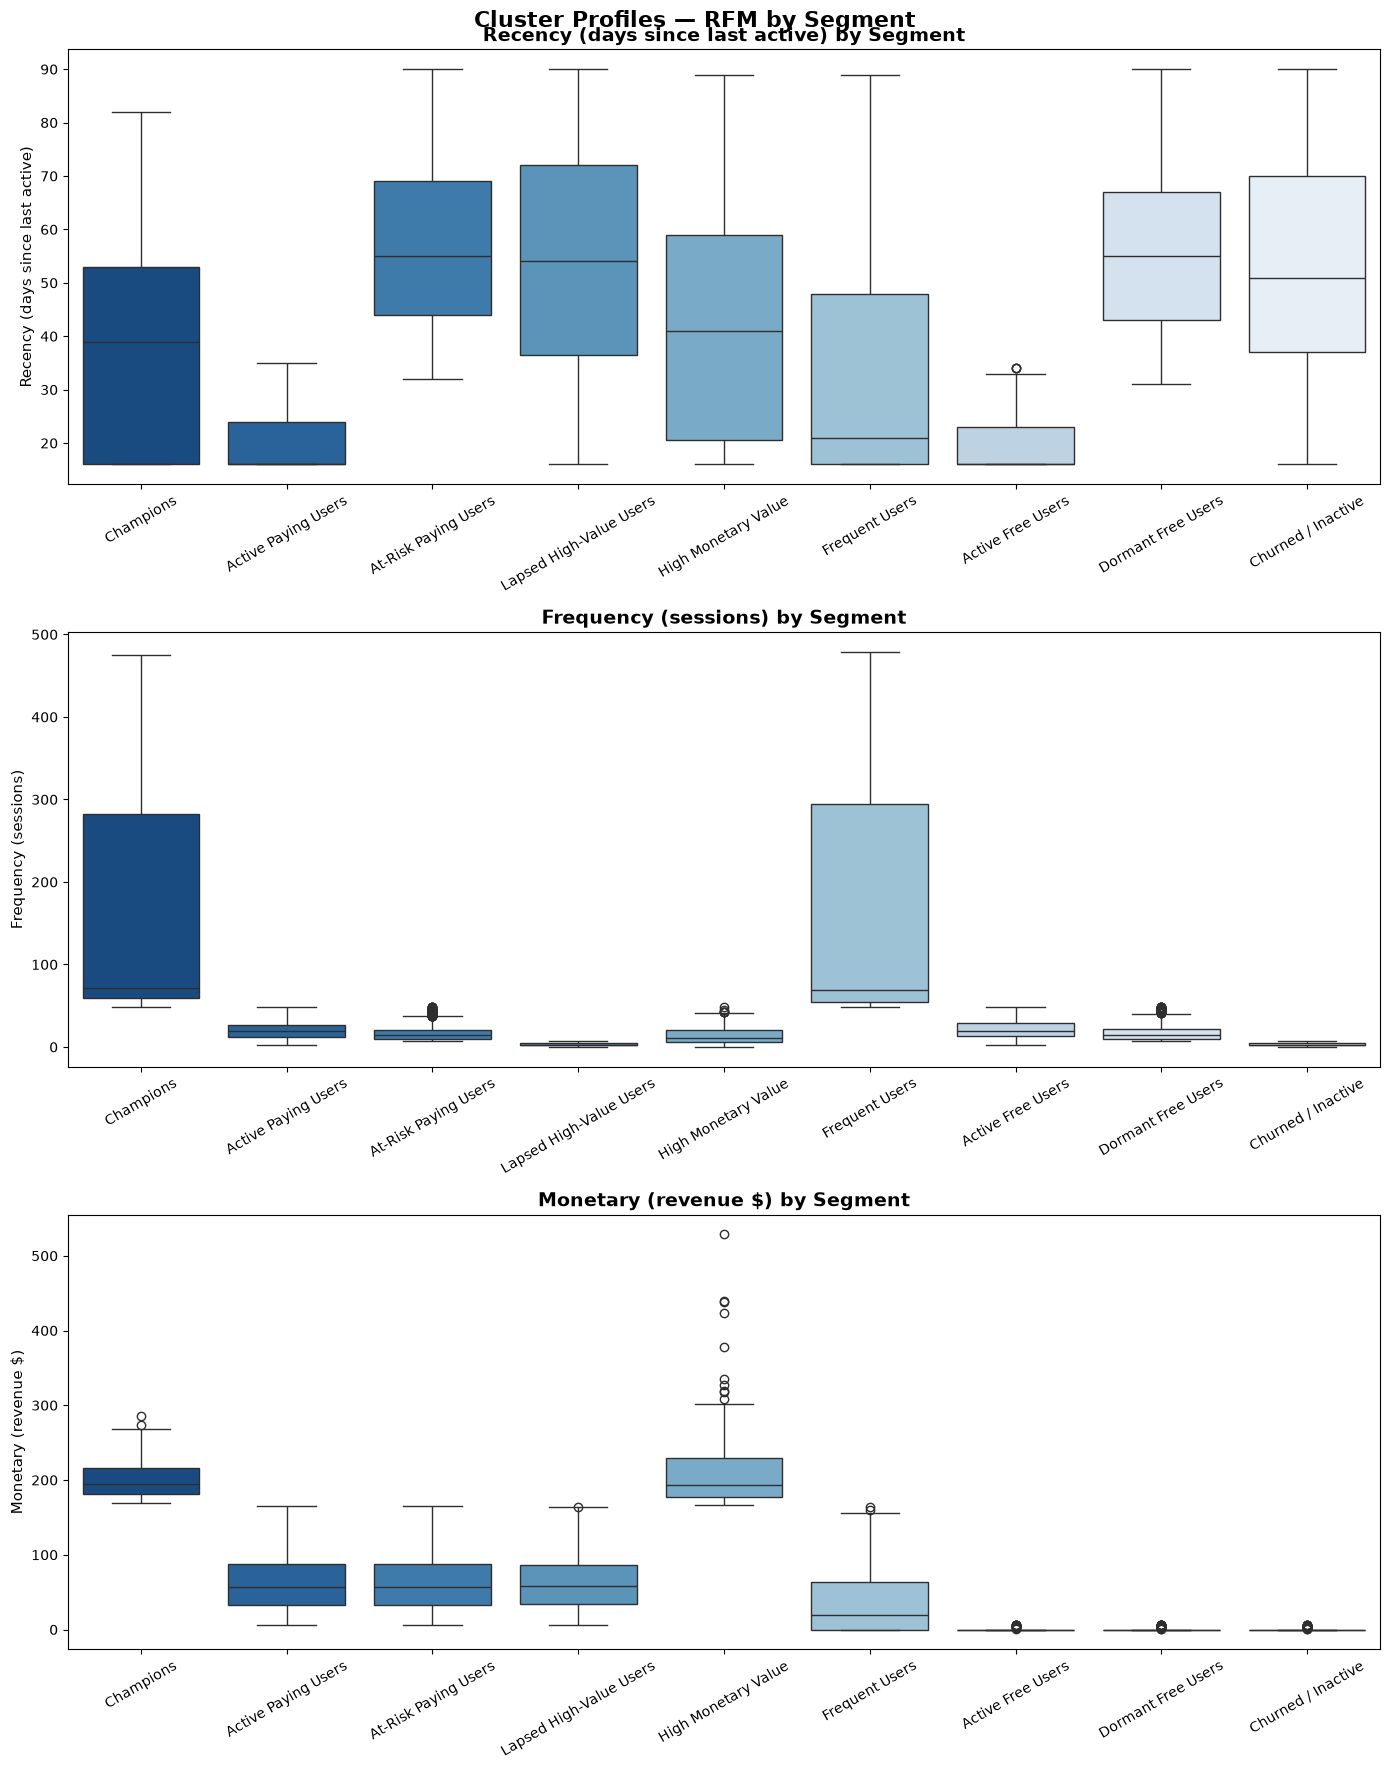

In [30]:
import seaborn as sns

cluster_order = [
    "Champions", "Active Paying Users", "At-Risk Paying Users",
    "Lapsed High-Value Users", "High Monetary Value", "Frequent Users",
    "Active Free Users", "Dormant Free Users", "Churned / Inactive"
]

palette = sns.color_palette("Blues_r", n_colors=len(cluster_order))

fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, col, label in zip(axes,
                           ["recency", "frequency", "monetary"],
                           ["Recency (days since last active)", "Frequency (sessions)", "Monetary (revenue $)"]):
    sns.boxplot(data=master_df, x="cluster", y=col, order=cluster_order,
                palette=palette, ax=ax)
    ax.set_title(f"{label} by Segment", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label, fontsize=11)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Cluster Profiles — RFM by Segment", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

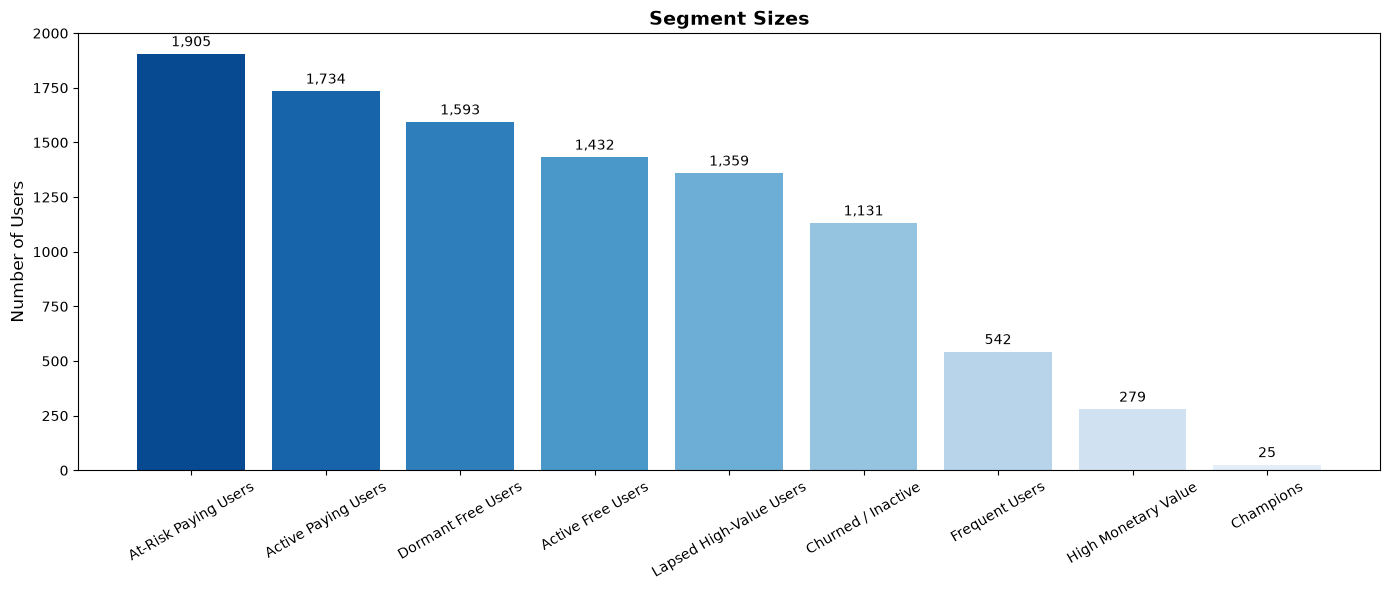

In [31]:
cluster_counts = master_df["cluster"].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(cluster_counts.index, cluster_counts.values,
              color=sns.color_palette("Blues_r", n_colors=len(cluster_counts)))

ax.set_title("Segment Sizes", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Users", fontsize=12)
ax.tick_params(axis="x", rotation=30)

for bar, val in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [33]:
master_df

,user_id,signup_date,last_active_date,total_sessions,revenue,acquisition_channel,recency,frequency,monetary,cluster
0,USER_0001,2024-02-17,2024-03-08,14,0.00,email,23,14,0.00,Active Free Users
1,USER_0002,2024-03-09,2024-03-09,4,0.00,paid_search,22,4,0.00,Churned / Inactive
2,USER_0003,2024-01-26,2024-03-05,25,54.50,paid_search,26,25,54.50,Active Paying Users
3,USER_0004,2024-03-08,2024-03-13,5,0.00,organic,18,5,0.00,Active Free Users
4,USER_0005,2024-01-24,2024-02-24,10,72.96,email,36,10,72.96,At-Risk Paying Users
...,...,...,...,...,...,...,...,...,...,...
9995,USER_1996,2024-03-08,2024-03-15,218,178.65,email,16,218,178.65,Champions
9996,USER_0014,2024-01-08,2024-02-21,282,176.89,social_media,39,282,176.89,Champions
9997,USER_7761,2024-01-22,2024-03-15,95,172.11,organic,16,95,172.11,Champions
9998,USER_6145,2024-02-05,2024-02-07,475,170.13,social_media,53,475,170.13,Champions
